##**Install Required Libraries**

##**Import Libraries**

In [63]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [64]:
# =========================
# 1. LOAD IMAGES
# =========================
def load_images(paths):
    images = []
    for path in paths:
        img = cv2.imread(path)
        if img is None:
            raise ValueError(f"Image not found at {path}")
        images.append(img)
    return images

In [65]:
# =========================
# 2. PREPROCESS (KEEP COLOR)
# =========================
def preprocess_images(images, size=(256, 256)):
    processed = []

    for img in images:
        img_resized = cv2.resize(img, size)
        normalized = img_resized / 255.0
        processed.append(normalized)

    return processed


In [66]:
# =========================
# 3. DISPLAY
# =========================
def show_images(images, titles):
    plt.figure(figsize=(12, 5))

    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)

        # if color image
        if len(images[i].shape) == 3:
            img = cv2.cvtColor((images[i]*255).astype(np.uint8), cv2.COLOR_BGR2RGB)
            plt.imshow(img)
        else:
            plt.imshow(images[i], cmap='gray')

        plt.title(titles[i])
        plt.axis('off')

    plt.show()

In [67]:
# =========================
# 4. PYRAMID FUNCTIONS
# =========================
def build_gaussian_pyramid(img, levels=5):
    gp = [img]
    for _ in range(levels):
        img = cv2.pyrDown(img)
        gp.append(img)
    return gp


def build_laplacian_pyramid(gp):
    lp = []
    for i in range(len(gp) - 1):
        size = (gp[i].shape[1], gp[i].shape[0])
        expanded = cv2.pyrUp(gp[i+1], dstsize=size)
        lap = gp[i] - expanded
        lp.append(lap)
    lp.append(gp[-1])
    return lp


def fuse_pyramids(lp1, lp2):
    fused = []
    for l1, l2 in zip(lp1, lp2):
        mask = np.abs(l1) > np.abs(l2)
        fused.append(np.where(mask, l1, l2))
    return fused


def reconstruct(lp):
    img = lp[-1]
    for i in range(len(lp)-2, -1, -1):
        size = (lp[i].shape[1], lp[i].shape[0])
        img = cv2.pyrUp(img, dstsize=size)
        img = img + lp[i]
    return img

In [68]:
# =========================
# 5. COLOR FUSION (FIXED)
# =========================
def fuse_color_images(img1, img2):
    channels = []

    for i in range(3):
        c1 = img1[:, :, i]
        c2 = img2[:, :, i]

        gp1 = build_gaussian_pyramid(c1)
        gp2 = build_gaussian_pyramid(c2)

        lp1 = build_laplacian_pyramid(gp1)
        lp2 = build_laplacian_pyramid(gp2)

        fused_lp = fuse_pyramids(lp1, lp2)
        fused = reconstruct(fused_lp)

        channels.append(fused)

    fused_img = np.stack(channels, axis=2)
    return fused_img

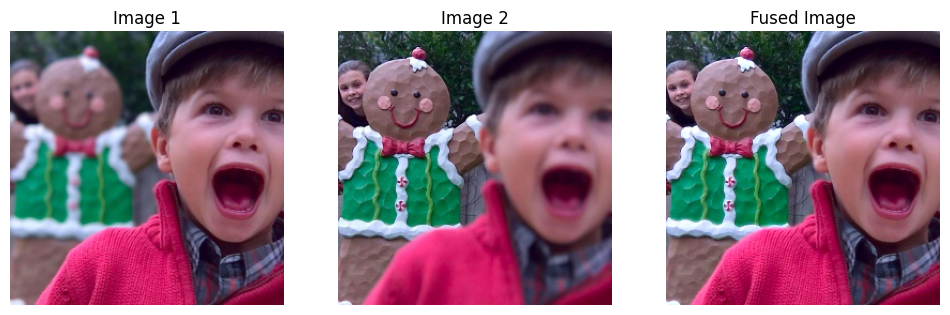

In [69]:
# =========================
# 6. RUN PIPELINE
# =========================
paths = ['/content/lytro-03-A.jpg', '/content/lytro-03-B.jpg']

images = load_images(paths)
processed_images = preprocess_images(images)

img1 = processed_images[0]
img2 = processed_images[1]

fused = fuse_color_images(img1, img2)
fused = np.clip(fused, 0, 1)

# Show results
show_images(
    [img1, img2, fused],
    ["Image 1", "Image 2", "Fused Image"]
)